In [142]:
#!pip install prophet
#!pip install tensorflow
#!pip install -q git+https://github.com/MJAHMADEE/docs
#!pip install --upgrade protobuf

In [201]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from tensorflow import keras
import tensorflow as tf 

from math import sqrt
import tensorflow.keras.backend as K
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from keras.callbacks import EarlyStopping
from tensorflow.keras import models, Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [202]:
# generate a synthetic energy data 
# generate 1 year hourly electricity data uptil (2026-06-20) with features "temperature", wind_generation, solar_generation,national_demand,gas_price
# hour, day_of_week, month, is_weekend,price_lag_1, price_lag_48, price_ma_48, price_ma_24

# end date 21/06/2026

# set the random number to 42
np.random.seed(42)

end_date = "2026-06-21 23:00:00"
start_date = pd.Timestamp(end_date) - pd.DateOffset(years=1)

dt = pd.date_range(start=start_date, end=end_date, freq="h")

n = len(dt)

# define dataframe for time features 
df = pd.DataFrame({"datetime": dt})

In [203]:
# define time features 

df["hour"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month

# once the day is greater than 5, then it is a weekend day
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

#day_of_year = df["datetime"].dt.dayofyear

In [204]:
# generate synthetic temperature data base on seasonal and daily patterns.
# use sine function to produce a smooth repeating pattern

#day_of_year = df["datetime"].dt.dayofyear, base temp is 12°C.
# denominator 24*365 = 8760, # let sine wave complete one full cycle every year
#beginning of year → around 12°C, middle of year → around 22°C (12 + 10), later in year → around 2°C (12 - 10), end of year → back to 12°C
# seasonal variation that generates a sine wave that oscillates between -10 and +10. ranges from -1 to +1 and 
# Generates n random values from a normal distribution, mean = 0, standard deviation = 2
# These random values are added to make temperatures less perfectly smooth.

df["temperature"] = (
    12
    + 10*np.sin(2*np.pi*df.index/(24*365))
    + np.random.normal(0,2,n)
)


In [205]:
# generate synthetic weather and solar generation 
# Generates n random numbers from a normal (Gaussian) distribution.
# 9000 is the mean (average).
# 2500 is the standard deviation (how spread out the values are).

df["wind_generation"] = np.random.normal(9000, 2500, n).clip(0)

# Create a daylight-shaped curve, If hour goes from 0 to 23, produces a half-sine wave representing sunlight intensity
# Remove nighttime values, any negative values (nighttime) become 0, 
# Scale to a peak of 6000, The sine wave peaks at 1, so, Sunrise ≈ 0, Noon ≈ 6000, Sunset ≈ 0, add random variation
# So solar generation is only positive between roughly 6 AM and 6 PM.
df["solar_generation"] = (
    np.maximum(
        0,
        np.sin(np.pi*(df["hour"]-6)/12)
    ) * 6000
    + np.random.normal(0,200,n)
).clip(0) # Prevent negative generation, If noise makes a value negative, it is clipped to 0.

In [206]:
# generate national demand
df["national_demand"] = (
    28000
    + 4000*np.sin(2*np.pi*(df["hour"]-7)/24)
    + np.random.normal(0,1000,n)
)

In [207]:
# generate gas price like time series that behaves like a random walk around a starting value of 65
# Creates n random numbers drawn from a normal distribution with Mean = 0, Standard deviation = 0.1
df["gas_price"] = (
    65
    + np.cumsum(np.random.normal(0,0.1,n)) # Accumulate the changes
)

In [208]:
# generate Synthetic electricity price
df["price_p_kwh"] = (
    50
    + 0.001*df["national_demand"]
    - 0.002*df["wind_generation"]
    - 0.001*df["solar_generation"]
    + 0.3*df["gas_price"]
    + np.random.normal(0,3,n)
)

In [209]:
# generate Lag features
df["price_lag_1"] = df["price_p_kwh"].shift(1)
df["price_lag_48"] = df["price_p_kwh"].shift(48)

# Moving averages
df["price_ma_24"] = df["price_p_kwh"].rolling(24).mean()
df["price_ma_48"] = df["price_p_kwh"].rolling(48).mean()



In [210]:
# National demand (MW) driven by temperature, hour, and weekends

temp_effect = np.abs(df["temperature"] - 18) * 600

hour_effect = (
    3000
    * np.sin(np.pi * (df["hour"] - 8) / 24) ** 2
)

weekend_effect = -2500 * df["is_weekend"]

df["national_demand"] = (
    28000
    + temp_effect
    + hour_effect
    + weekend_effect
    + np.random.normal(0, 1200, len(df))
)

df.head(5)

,datetime,hour,day_of_week,month,is_weekend,temperature,wind_generation,solar_generation,national_demand,gas_price,price_p_kwh,price_lag_1,price_lag_48,price_ma_24,price_ma_48
0,2025-06-21 23:00:00,23,5,6,1,12.993428,5761.853448,0.000000,29927.767007,64.970156,84.080460,NaN,NaN,NaN,NaN
1,2025-06-22 00:00:00,0,6,6,1,11.730644,6031.117083,339.103164,34489.931582,64.833596,85.626289,84.080460,NaN,NaN,NaN
2,2025-06-22 01:00:00,1,6,6,1,13.309722,10447.274545,0.000000,31792.415697,64.643549,75.355395,85.626289,NaN,NaN,NaN
3,2025-06-22 02:00:00,2,6,6,1,15.067577,8839.155882,291.081896,27830.157309,64.494201,74.852878,75.355395,NaN,NaN,NaN
4,2025-06-22 03:00:00,3,6,6,1,11.560384,7862.070540,0.000000,30581.694013,64.469930,78.744569,74.852878,NaN,NaN,NaN


In [211]:
# Data cleansing, drp any column with NAN and missing values
df = df.dropna()
n_df = len(df)
print(n_df)

# This will produce approximately 8,700 hourly records covering the last year through 2026-06-20 with all requested features.

8713


In [212]:
# check the dataset cells info
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8713 entries, 48 to 8760
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          8713 non-null   datetime64[ns]
 1   hour              8713 non-null   int32         
 2   day_of_week       8713 non-null   int32         
 3   month             8713 non-null   int32         
 4   is_weekend        8713 non-null   int64         
 5   temperature       8713 non-null   float64       
 6   wind_generation   8713 non-null   float64       
 7   solar_generation  8713 non-null   float64       
 8   national_demand   8713 non-null   float64       
 9   gas_price         8713 non-null   float64       
 10  price_p_kwh       8713 non-null   float64       
 11  price_lag_1       8713 non-null   float64       
 12  price_lag_48      8713 non-null   float64       
 13  price_ma_24       8713 non-null   float64       
 14  price_ma_48       8713 non-n

In [213]:
# Data Visualization

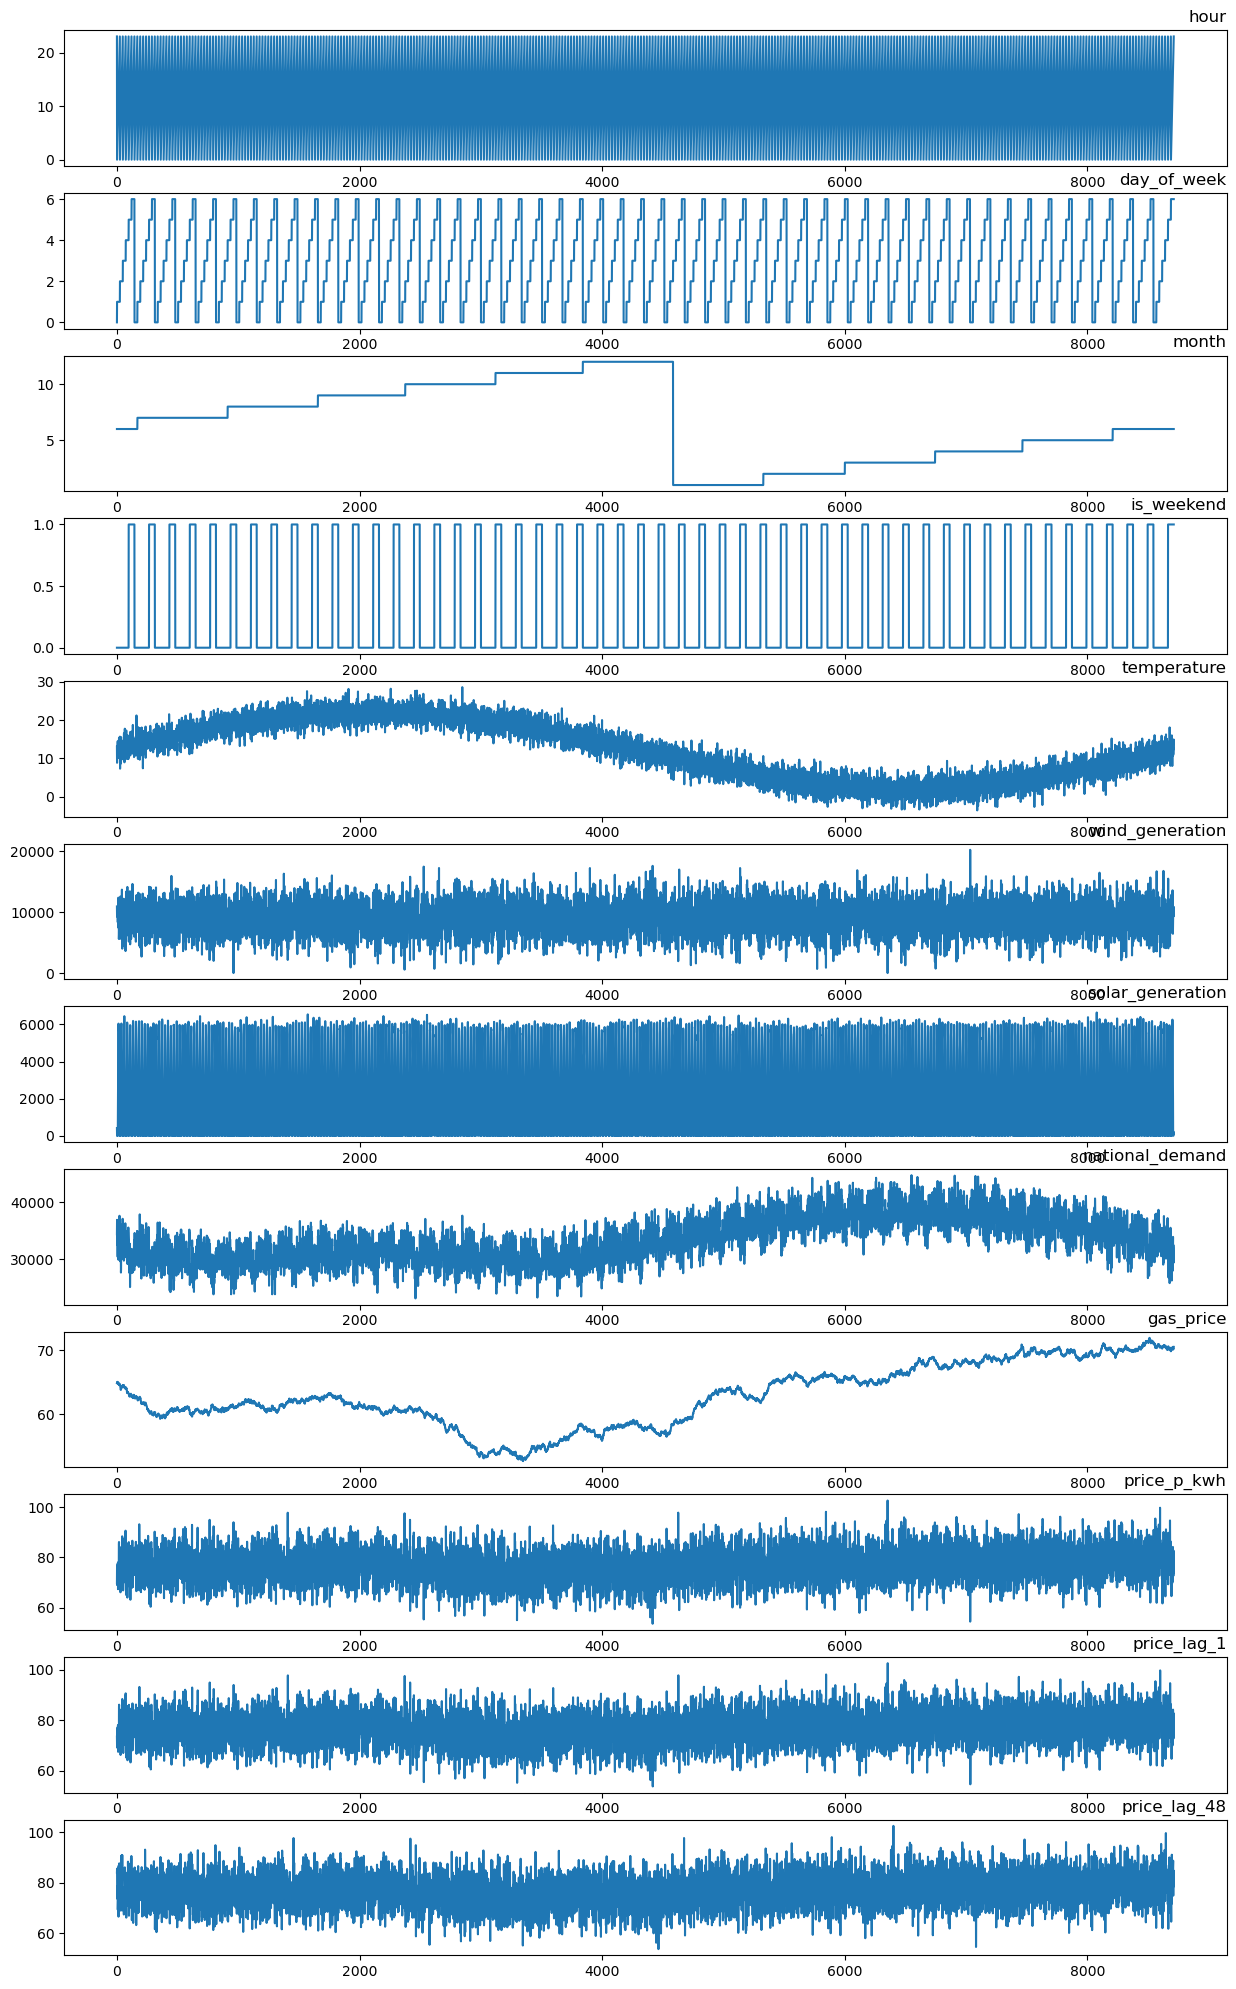

In [214]:
# plot each column as a an independent subplot against datetime
columns = ["datetime", "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "temperature",
    "wind_generation",
    "solar_generation",
    "national_demand",
    "price_p_kwh"
    "gas_price",
    "price_lag_1",
    "price_lag_48",
    "price_ma_24",
    "price_ma_48"
]

# set datetime as index 
df_with_datetime_index = df.set_index("datetime")
values = df_with_datetime_index.values

# specify columns to plot 
cols = [0,1,2,3,4,5,6,7,8,9,10,11]
i = 1

# plot each column 
plt.figure(figsize=(15,25))
for col in cols:
    plt.subplot(len(cols), 1, i)
    plt.plot(values[:, col])
    plt.title(df_with_datetime_index.columns[col], loc="right") 
    i+=1
plt.savefig("feature_data.png")
plt.show()

In [215]:
df_with_datetime_index.head(4)

,hour,day_of_week,month,is_weekend,temperature,wind_generation,solar_generation,national_demand,gas_price,price_p_kwh,price_lag_1,price_lag_48,price_ma_24,price_ma_48
datetime,,,,,,,,,,,,,,
2025-06-23 23:00:00,23,0,6,0,13.031453,10918.268407,412.165313,34353.175970,64.835036,69.829089,73.458767,84.080460,78.636446,77.774768
2025-06-24 00:00:00,0,1,6,0,8.825304,9360.633806,0.000000,36870.466189,64.916213,76.893721,69.829089,85.626289,78.966911,77.592840
2025-06-24 01:00:00,1,1,6,0,13.006720,9826.959516,0.000000,32510.253833,64.961195,69.042531,76.893721,75.355395,78.601797,77.461322
2025-06-24 02:00:00,2,1,6,0,11.595556,9212.163646,0.000000,34999.071018,65.035387,73.938934,69.042531,74.852878,78.745525,77.442281


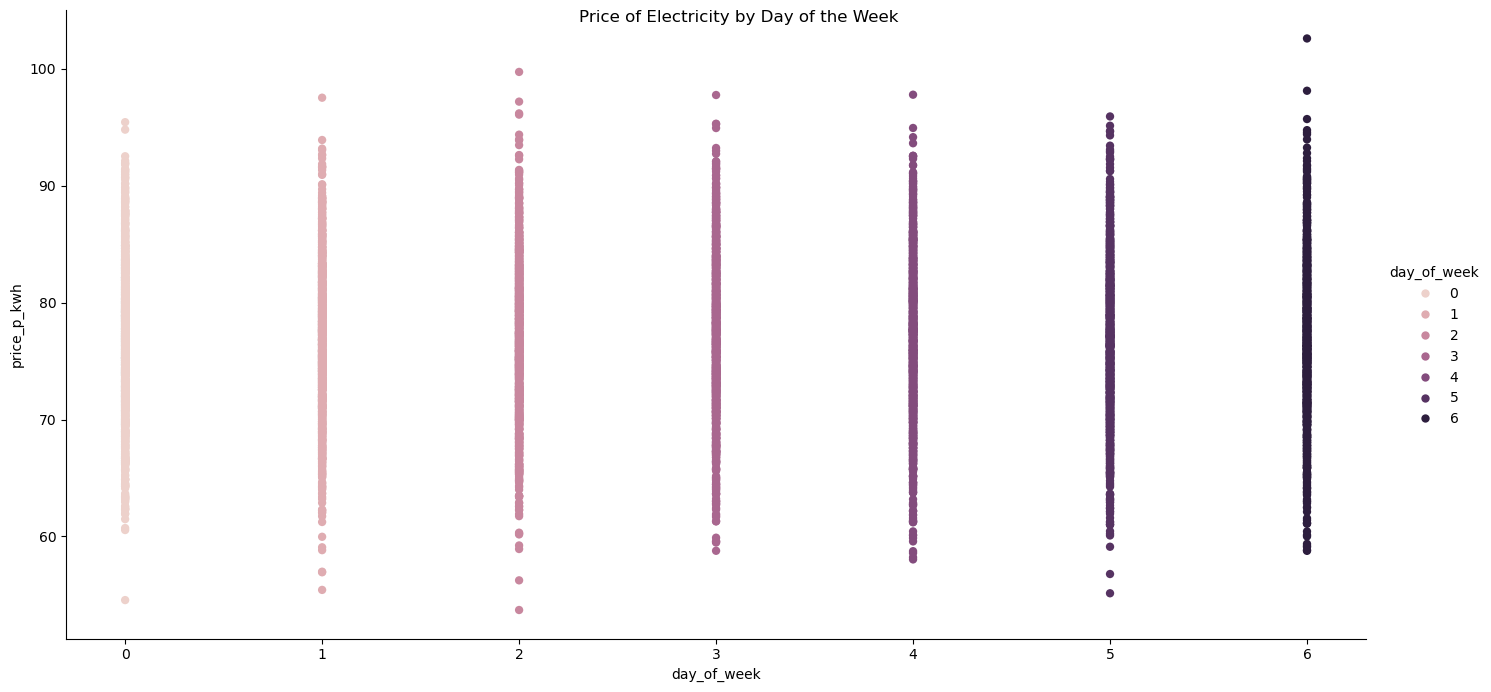

In [216]:
# craete new data frame with price_p_kwh as target  and feature as day_of_week to see the seasonal trend of the price

def feature_with_price_p_kwh(df, label="None"):
    X = df[["day_of_week"]]
    if label:
        y = df[[label]]
        return X, y 
    return X 

X,y = feature_with_price_p_kwh(df, label="price_p_kwh")

feature_and_target = pd.concat([X,y], axis=1)

# plot the new dataframe to see trend 

sns.pairplot(feature_and_target, hue="day_of_week", x_vars=["day_of_week"], y_vars="price_p_kwh", height=7, aspect=2, plot_kws={'alpha':1.0, 'linewidth':0})
plt.suptitle("Price of Electricity by Day of the Week")
plt.savefig("Price_per_day.png")
plt.show()

In [217]:
# ADF test for statinarity with coint johansen: Augmented Dickey-Fuller (ADF) 
# to see if time series analysis data series is stationary or contains a unit root
coint_johansen( df_with_datetime_index.iloc[: , :11], 1 ,1).eig

array([ 3.36079560e-01,  2.72592932e-01,  2.44605676e-01,  2.13195493e-01,
        1.83942521e-01,  5.79045388e-02,  2.24658266e-02,  1.84443176e-02,
        1.75033030e-03,  5.04661541e-04, -1.42686212e-07])

In [218]:
# split the new df with time column into 66% train set and 34% test set to train for univaritiate forecasting 
train_size = int(len(df_with_datetime_index) * 0.66)
test_size = int(len(df_with_datetime_index)* 0.34)

train_arr = df_with_datetime_index[0:train_size]
test_arr = df_with_datetime_index[train_size:]

In [219]:
# Feature Engineering 
target_train = train_arr["price_p_kwh"]
target_test = test_arr["price_p_kwh"]

feature_train = train_arr[["hour","day_of_week","month","is_weekend","temperature","wind_generation","solar_generation","national_demand","gas_price",
    "price_lag_1","price_lag_48","price_ma_24","price_ma_48"]]
feature_test = test_arr[["hour","day_of_week","month","is_weekend","temperature","wind_generation","solar_generation","national_demand","gas_price",
    "price_lag_1","price_lag_48","price_ma_24","price_ma_48"]]

# ensure all data is float
target_train_values = target_train.values.astype('float32')
target_test_values = target_test.values.astype('float32')
feature_train_values = feature_train.values.astype('float32')
feature_test_values = feature_test.values.astype('float32')


In [220]:
# normalise all features to be within range 0 to 1 
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train_feature = scaler.fit_transform(feature_train_values)
scaled_test_feature = scaler.fit_transform(feature_test_values)
scaled_target_train = scaler.fit_transform(target_train_values.reshape(-1,1))
scaled_target_test = scaler.fit_transform(target_test_values.reshape(-1,1))

In [221]:
# predict time series with LSTM
# convert multivarite time series to supervised learning using lookbacl 24hr time steps

def temporalize(X, y, lookback=1): 
    output_X = []
    output_y = []
    for i in range(len(X) - lookback -1):
        t = []
        for j in range(1, lookback + 1):
            # gather past records upto the lookback period
            t.append(X[[(i+j+1)], :])
        output_X.append(t)
        output_y.append(y[i+lookback+1])
    return np.array(output_X), np.array(output_y)
lookback = 24
trainX, trainy = temporalize(scaled_train_feature,scaled_target_train, lookback)
testX, testy = temporalize(scaled_test_feature, scaled_target_test,lookback)

# Reshape the input data into n__samples, X-timesteps, X-n_features
num_features = 13
reshapeXtrain = trainX.reshape(trainX.shape[0], lookback, num_features)
reshapeXtest = testX.reshape(testX.shape[0], lookback, num_features)
testy.shape

(2938, 1)

In [223]:

# define custom RMSE 
def rmse(test_y, yhat):
    # Calculate the mean squared error for each sample over axis=-1
    mse = K.mean(K.square(yhat - test_y), axis=-1)
    # Return the square root of that mean
    return K.sqrt(mse)

# define mean square error fn 
def mean_squared_error(test_y, yhat):
    return K.mean(K.square(yhat - test_y), axis=-1)

# We can test the custom metrics with the regression problem by passing the method directly in the metrics

model = Sequential()
model.add(LSTM(100, input_shape=(reshapeXtrain.shape[1], reshapeXtrain.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss = 'mean_squared_error', optimizer='adam', metrics=[rmse])
# plot history 
history_model_1 = model.fit(reshapeXtrain, trainy, epochs=20, batch_size=200, validation_data=(reshapeXtest, testy), 
                    callbacks=[EarlyStopping(monitor='val loss', patience=10, mode='min')], verbose=1, shuffle=False)

history_dict = history_model_1.history
# Save it under the form of a json file
json.dump(history_dict, open('history1.json', 'w'))
model.summary()


Epoch 1/20


C:\Users\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0494 - rmse: 0.1747 - val_loss: 0.0182 - val_rmse: 0.1080
Epoch 2/20
 7/29 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0237 - rmse: 0.1236

C:\Users\anaconda\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning:

Early stopping conditioned on metric `val loss` which is not available. Available metrics are: loss,rmse,val_loss,val_rmse



29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0251 - rmse: 0.1261 - val_loss: 0.0290 - val_rmse: 0.1381
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0253 - rmse: 0.1279 - val_loss: 0.0252 - val_rmse: 0.1282
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0233 - rmse: 0.1219 - val_loss: 0.0273 - val_rmse: 0.1347
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0226 - rmse: 0.1204 - val_loss: 0.0217 - val_rmse: 0.1188
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0209 - rmse: 0.1155 - val_loss: 0.0248 - val_rmse: 0.1284
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0204 - rmse: 0.1138 - val_loss: 0.0222 - val_rmse: 0.1212
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0189 - rmse: 0.1094 - val_loss: 0.0208 - val_rmse: 0.1171
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0178 - rmse: 0.1061 - val_loss: 0.0190 - val_rmse: 0.1117
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss:

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 100)            │        45,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,105 (535.57 KB)

 Trainable params: 45,701 (178.52 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 91,404 (357.05 KB)

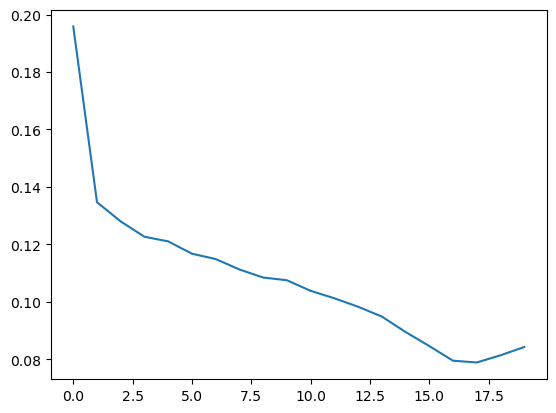

In [167]:
# plot lineplot of the custom rmse 
plt.plot(history_model_1.history['rmse'])
plt.show()

In [168]:
# invert predictions and test data 
reset_time = df.reset_index(drop=True)
y_hat_1 = scaler.inverse_transform(y_hat_1)
testy = scaler.inverse_transform(testy)
y_hat_1.shape

(2938, 1)

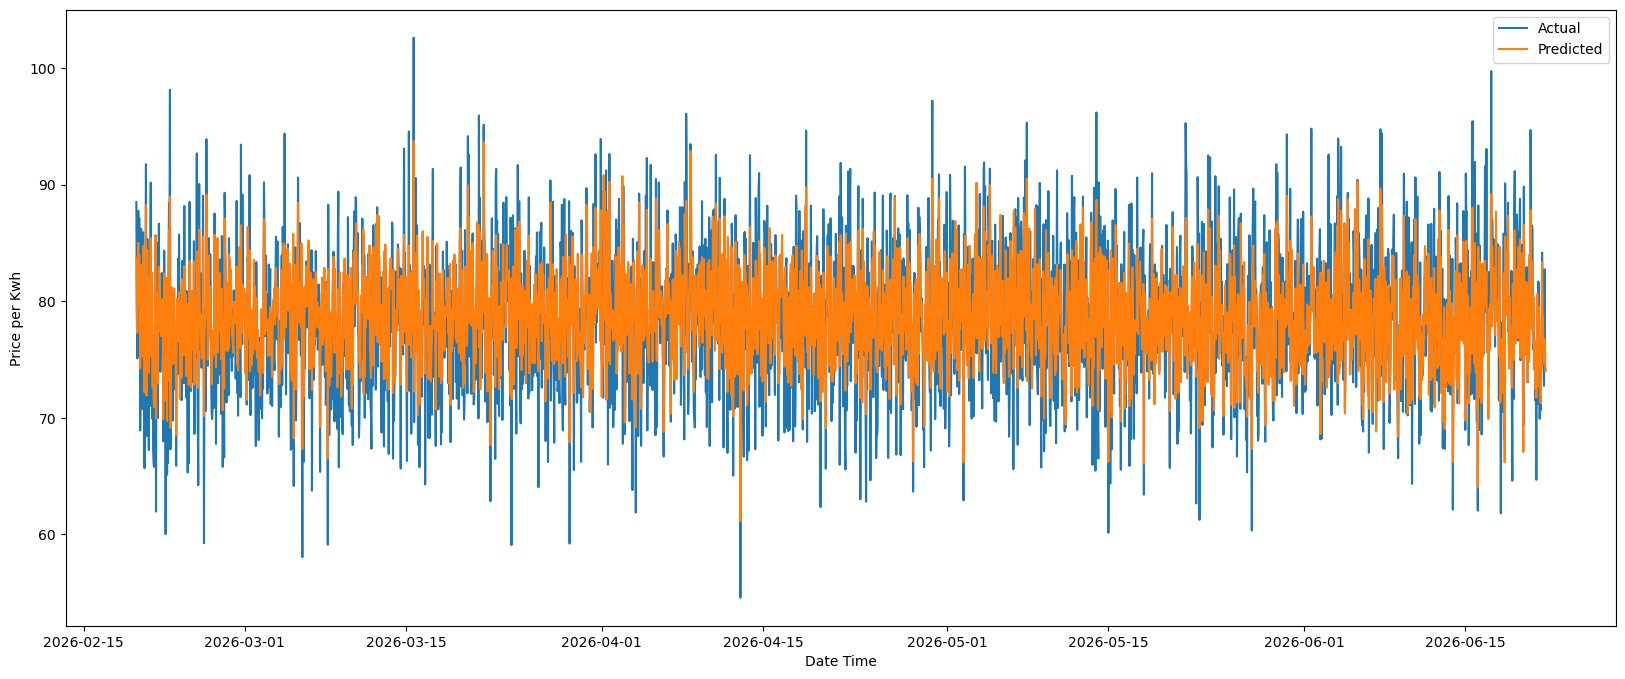

In [169]:
# plot predicted vs actual
plt.figure(figsize=(20,8))
plt.plot(reset_time["datetime"][-2938:], testy.reshape(-1,1), label="Actual")
plt.plot(reset_time["datetime"][-2938:], y_hat_1.reshape(-1,1), label="Predicted")
plt.ylabel("Price per Kwh")
plt.xlabel("Date Time")
plt.legend()
plt.savefig("24hr-multi-lstm-prediction")
plt.show()

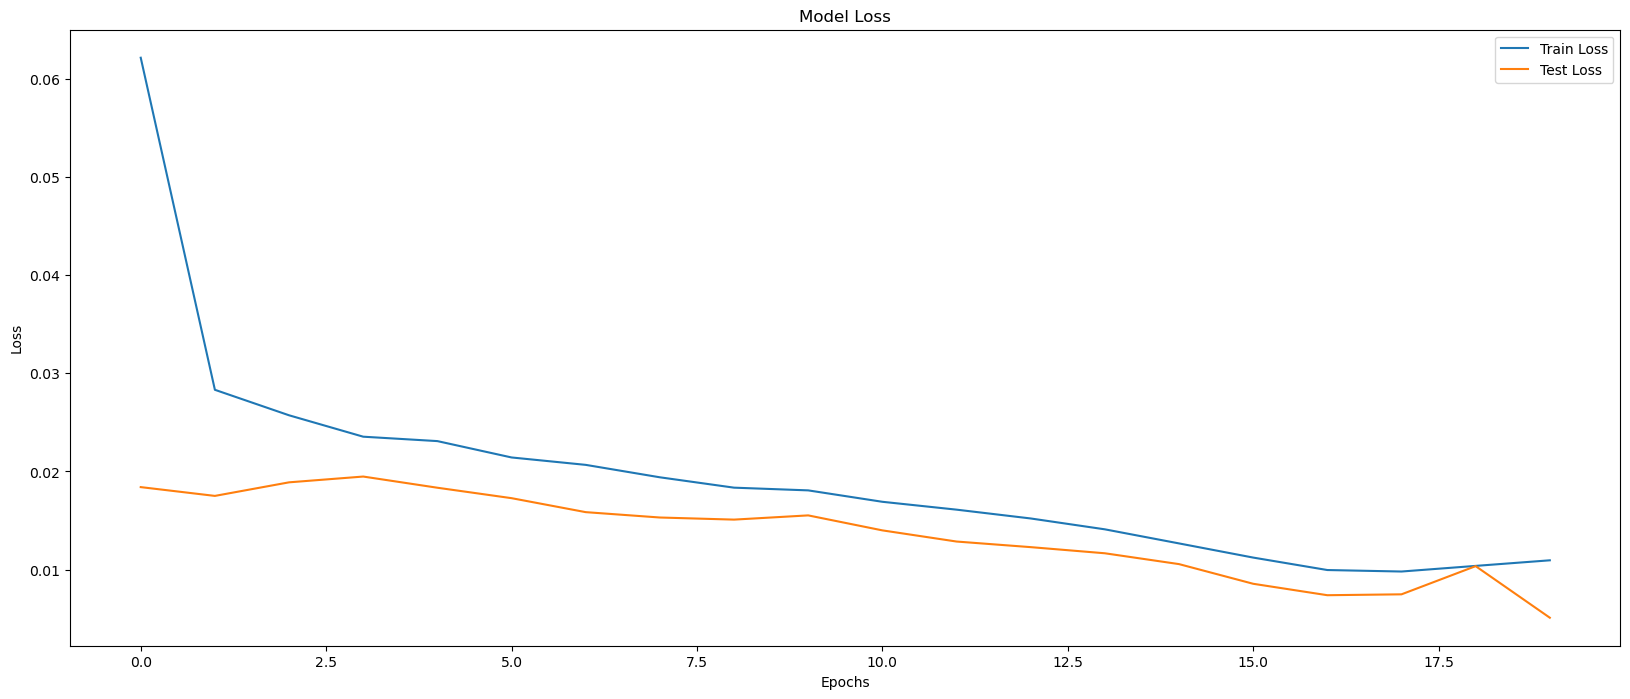

In [171]:
# plot loss 
plt.figure(figsize=(20,8))
plt.plot(history_model_1.history["loss"], label="Train Loss")
plt.plot(history_model_1.history["val_loss"], label="Test Loss")
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(loc="upper right")
plt.savefig("24hr-multi-lstm-loss.png")
plt.show()

In [172]:
# Univariate prediction of only electricity data 
price_data = df_with_datetime_index["price_p_kwh"]
price_data_values = price_data.values
# ensure float 
price_data = price_data_values.astype('float32')
price_data = np.reshape(price_data, (-1,1))

# normalise data 
#scaled_price_data = scaler.fit_transform(price_data)

# split into train and test set 
train_size = int(len(price_data)*0.66)
test_size = int(len(price_data)*0.34)


train, test = price_data[0:train_size,:], price_data[train_size:len(price_data),:]
train.shape

(5750, 1)

In [173]:
# convert univeriate time series to supervised learning using lookbacl 24hr time steps

def temporalize_uni(dataset, look_back=1): 
    output_X = []
    output_y = []
    for i in range(len(dataset) - look_back -1):
            # gather past records upto the lookback period
        a = dataset[i:(i+look_back), 0]
        output_X.append(a)
        output_y.append(dataset[i+look_back,0])
    return np.array(output_X), np.array(output_y)

look_back = 24 
X_train, y_train = temporalize_uni(train, look_back)
X_test, y_test = temporalize_uni(test, look_back)
X_test.shape
X_train.shape

(5725, 24)

In [174]:
# Reshape the input data into n__samples, X-timesteps, X-n_features
#reshapeXtrain = trainX.reshape(trainX.shape[0], lookback, num_features)

X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
X_test.shape

(2938, 1, 24)

In [175]:
# define root mean square error
def rmse(test_y, yhat):
    # Calculate the mean squared error for each sample over axis=-1
    mse = K.mean(K.square(yhat - test_y), axis=-1)
    # Return the square root of that mean
    return K.sqrt(mse)

model = Sequential()
model.add(LSTM(20, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(loss = 'mean_squared_error', optimizer='adam', metrics=[rmse])
# plot history 
history_model_2 = model.fit(X_train, y_train, epochs=20, batch_size=100, validation_data=(X_test, y_test), 
                    callbacks=[EarlyStopping(monitor='val loss', patience=10, mode='min')], verbose=1, shuffle=False)

history_dict2 = history_model_2.history
# Save it under the form of a json file
json.dump(history_dict, open('history2.json', 'w'))
model.summary()
# predict the test set using LSTM 
y_hat_2 = model.predict(X_test, verbose=0)

Epoch 1/20


C:\Users\anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 5696.5244 - rmse: 75.4651 - val_loss: 6007.8296 - val_rmse: 77.5065
Epoch 2/20
50/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5680.6477 - rmse: 75.3627

C:\Users\anaconda\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning:

Early stopping conditioned on metric `val loss` which is not available. Available metrics are: loss,rmse,val_loss,val_rmse



58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5618.0044 - rmse: 74.9436 - val_loss: 5962.5693 - val_rmse: 77.2139
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5575.1348 - rmse: 74.6571 - val_loss: 5918.6816 - val_rmse: 76.9292
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5532.8813 - rmse: 74.3726 - val_loss: 5875.4961 - val_rmse: 76.6480
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5491.8228 - rmse: 74.0965 - val_loss: 5832.7666 - val_rmse: 76.3688
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5451.2729 - rmse: 73.8218 - val_loss: 5790.4873 - val_rmse: 76.0914
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5409.8867 - rmse: 73.5403 - val_loss: 5748.4248 - val_rmse: 75.8146
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5367.4253 - rmse: 73.2522 - val_loss: 5706.4893 - val_rmse: 75.5375
Epoch 9/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5328.2622 - rmse: 72.9828 - val_loss: 5664.9819 - val_rmse: 75.2622
Epo

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 20)             │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,865 (42.45 KB)

 Trainable params: 3,621 (14.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,244 (28.30 KB)

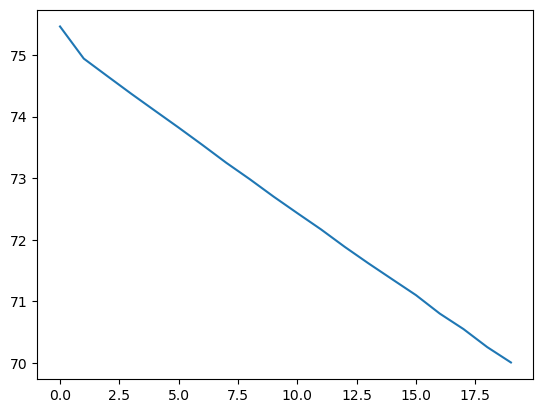

In [176]:
# plot lineplot of the custom rmse 
plt.plot(history_model_2.history['rmse'])
plt.show()

In [177]:
# invert predictions and test data 
reset_time = df.reset_index(drop=True)
y_hat_2 = scaler.inverse_transform(y_hat_2)
y_test = scaler.inverse_transform([y_test])
y_hat_2.shape

(2938, 1)

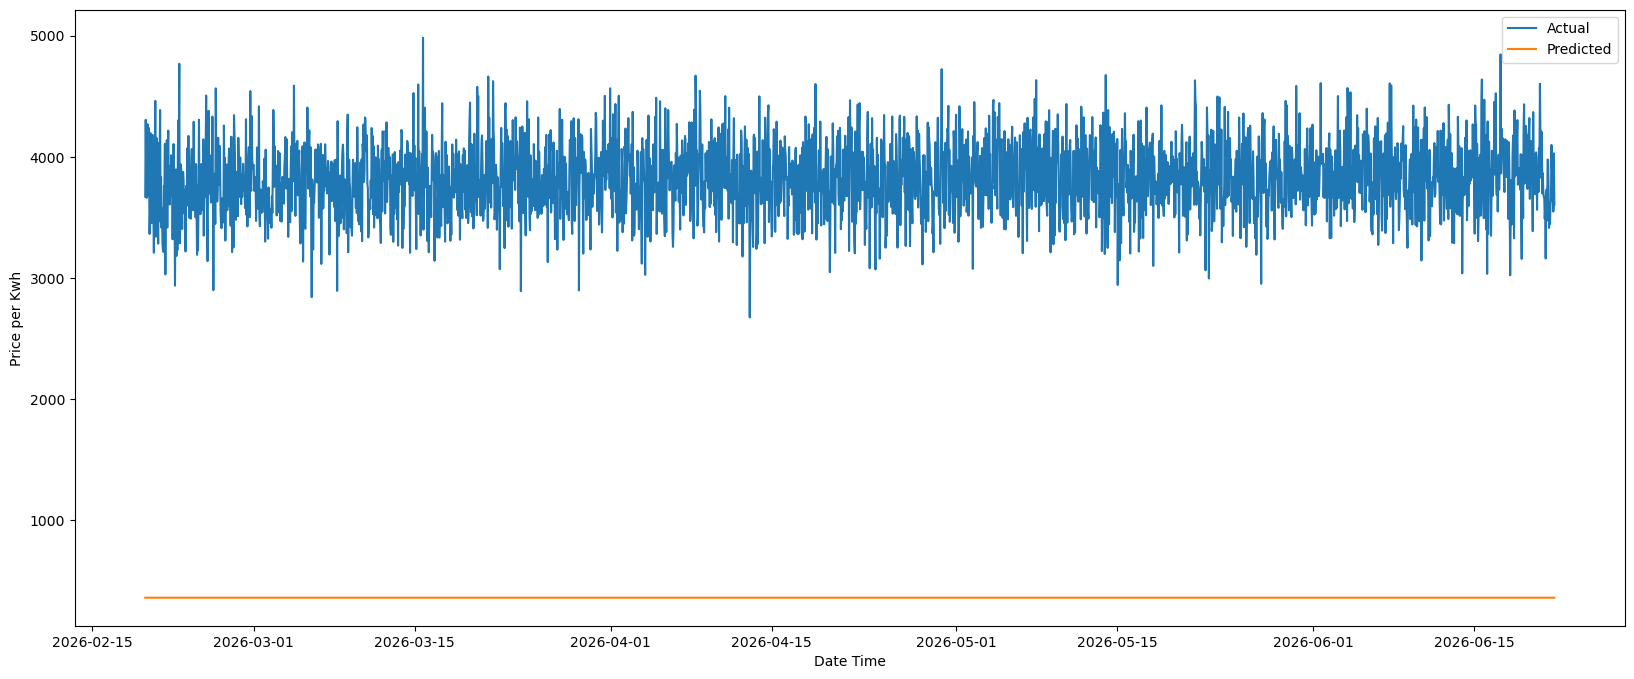

In [178]:
# plot predicted vs actual
plt.figure(figsize=(20,8))
plt.plot(reset_time["datetime"][-2938:], y_test.reshape(-1,1), label="Actual")
plt.plot(reset_time["datetime"][-2938:], y_hat_2.reshape(-1,1), label="Predicted")
plt.ylabel("Price per Kwh")
plt.xlabel("Date Time")
plt.legend()
plt.savefig("24hr-univa-lstm-prediction")
plt.show()

In [179]:
price_data = df[['datetime','price_p_kwh']]
price_data.columns = ['ds', 'y']
price_data.shape

# create test dataset, remove last 2000 rows
train_price_data = df.drop(df.index[-2000:])
train_price_data.shape

(6713, 15)

In [276]:
# forcast with Prophet model for univariate timeseries

model_p = Prophet(changepoint_prior_scale=0.05, seasonality_mode='multiplicative') 
model_p.add_country_holidays(country_name='UK')
# train on 75% of the train data
model_p.fit(price_data[price_data['ds']>pd.to_datetime('2026-03-30 11:00:00')])

# predict next day price, period = 1day
future = model_p.make_future_dataframe(periods=1)
# predcit on 25% test data

forecast = model_p.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecast

12:29:52 - cmdstanpy - INFO - Chain [1] start processing
12:29:52 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Boxing Day,Boxing Day_lower,Boxing Day_upper,Boxing Day (observed),...,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,weekly,weekly_lower,weekly_upper,additive_terms,additive_terms_lower,additive_terms_upper,yhat
0,2026-03-30 12:00:00,79.020201,71.292165,86.319299,79.020201,79.020201,0.0,0.0,0.0,0.0,...,-0.000678,-0.000678,-0.000678,-0.002152,-0.002152,-0.002152,0.0,0.0,0.0,78.966648
1,2026-03-30 13:00:00,79.019091,71.657912,86.845235,79.019091,79.019091,0.0,0.0,0.0,0.0,...,0.005727,0.005727,0.005727,-0.002148,-0.002148,-0.002148,0.0,0.0,0.0,79.471599
2,2026-03-30 14:00:00,79.017981,72.681880,86.978895,79.017981,79.017981,0.0,0.0,0.0,0.0,...,0.010870,0.010870,0.010870,-0.002146,-0.002146,-0.002146,0.0,0.0,0.0,79.876890
3,2026-03-30 15:00:00,79.016871,72.652848,87.749798,79.016871,79.016871,0.0,0.0,0.0,0.0,...,0.016480,0.016480,0.016480,-0.002141,-0.002141,-0.002141,0.0,0.0,0.0,80.319030
4,2026-03-30 16:00:00,79.015761,73.274546,88.827403,79.015761,79.015761,0.0,0.0,0.0,0.0,...,0.023643,0.023643,0.023643,-0.002133,-0.002133,-0.002133,0.0,0.0,0.0,80.883927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2000,2026-06-21 20:00:00,79.135630,71.900111,87.496519,79.135630,79.135630,0.0,0.0,0.0,0.0,...,0.009100,0.009100,0.009100,-0.003468,-0.003468,-0.003468,0.0,0.0,0.0,79.855767
2001,2026-06-21 21:00:00,79.136159,71.688377,86.454250,79.136159,79.136159,0.0,0.0,0.0,0.0,...,-0.005918,-0.005918,-0.005918,-0.003298,-0.003298,-0.003298,0.0,0.0,0.0,78.667863
2002,2026-06-21 22:00:00,79.136688,70.292369,85.336717,79.136688,79.136688,0.0,0.0,0.0,0.0,...,-0.017081,-0.017081,-0.017081,-0.003136,-0.003136,-0.003136,0.0,0.0,0.0,77.784927
2003,2026-06-21 23:00:00,79.137217,69.551757,84.895068,79.137217,79.137217,0.0,0.0,0.0,0.0,...,-0.022992,-0.022992,-0.022992,-0.002986,-0.002986,-0.002986,0.0,0.0,0.0,77.317730


In [181]:
# Python




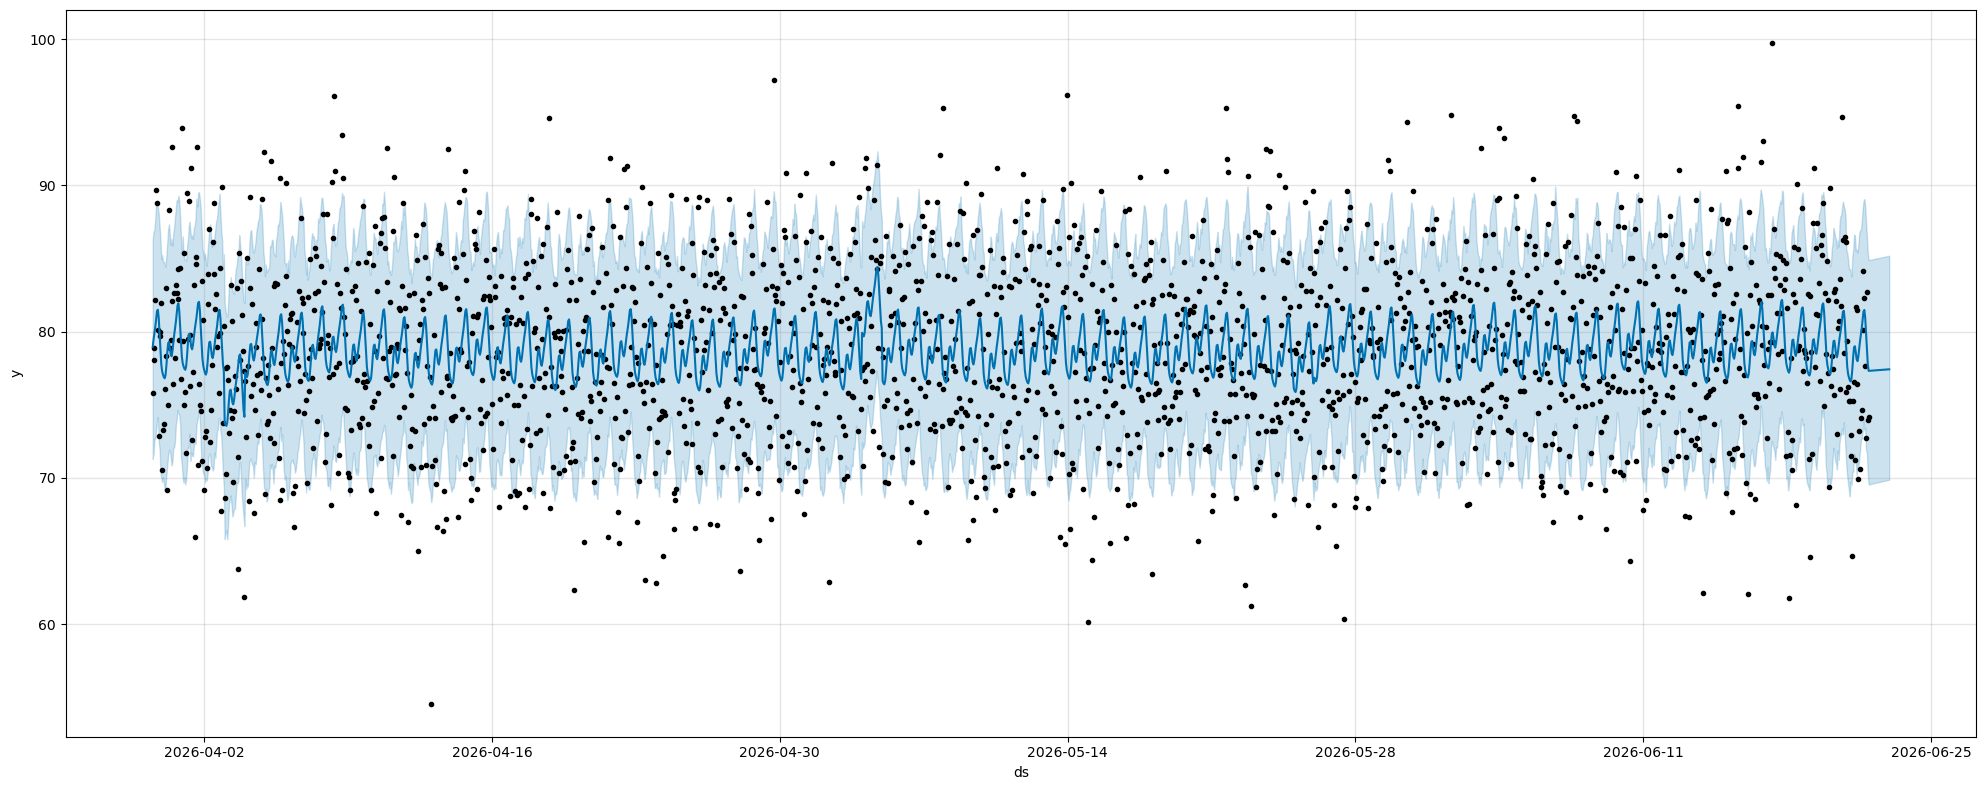

In [182]:
# plot the forcast 
fig1 = model_p.plot(forecast, figsize=(20,8))
plt.savefig('prophet-1-day.png')


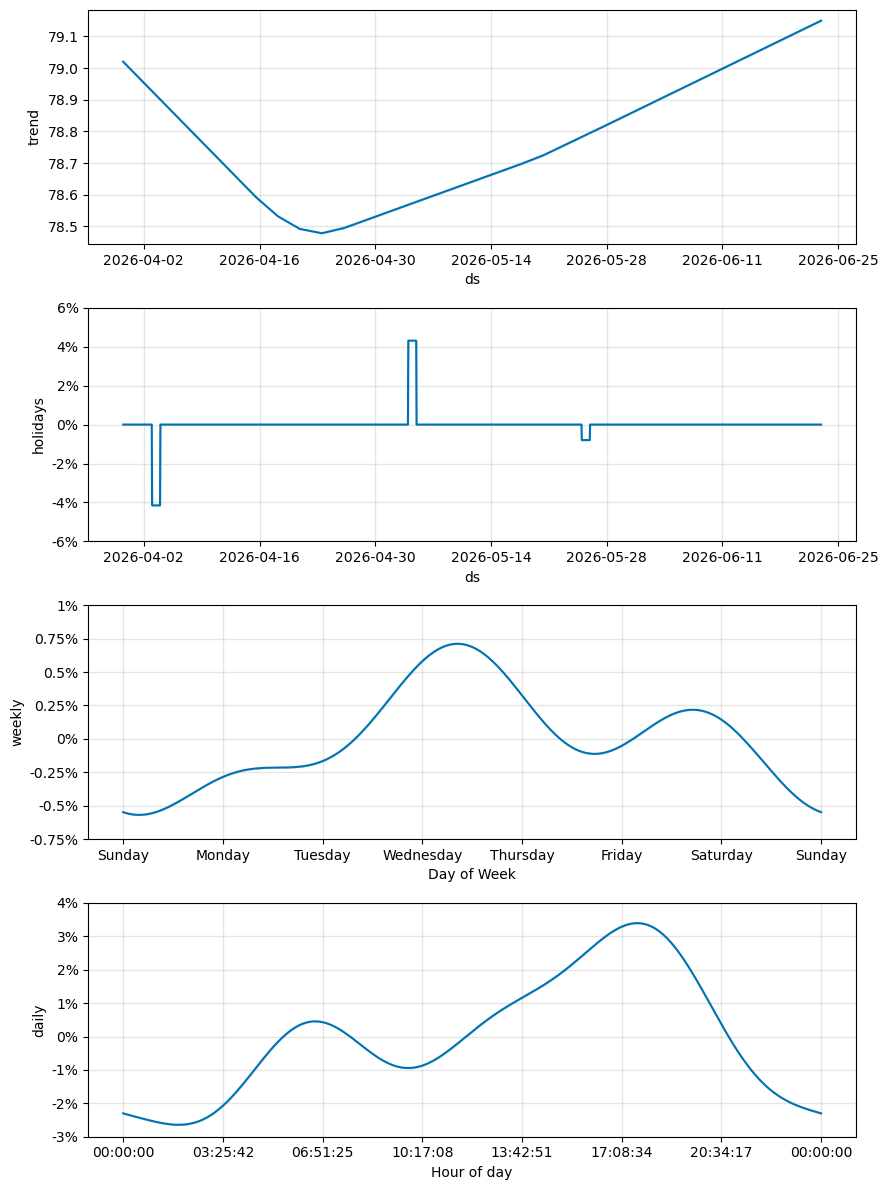

In [183]:
fig2 = model_p.plot_components(forecast)
plt.savefig('prophet-1-day-comp.png')


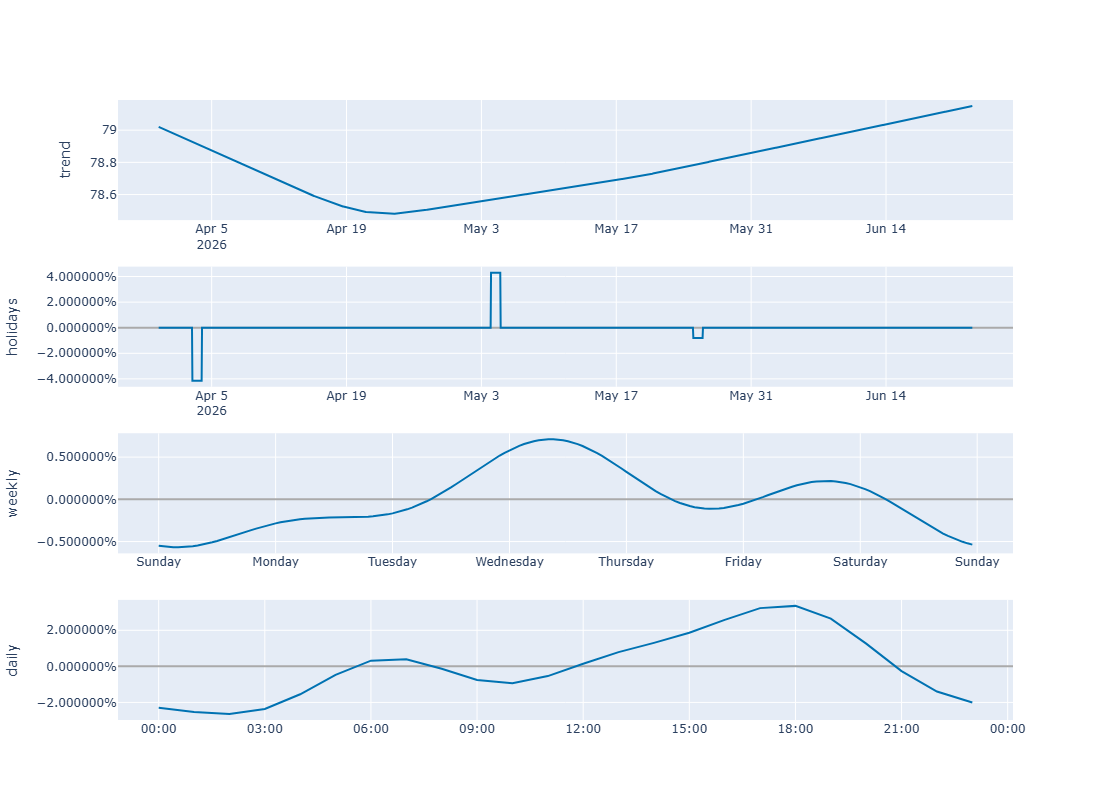

In [184]:
# plot interactive fifure
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(model_p, forecast)
plot_components_plotly(model_p, forecast)



In [185]:
# calculate error

# calculate MAE between expected and predicted values for december
y_true = price_data['y'][-2005:].values
y_pred = forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
print('MAE: %.3f' % mae)

MAE: 4.782


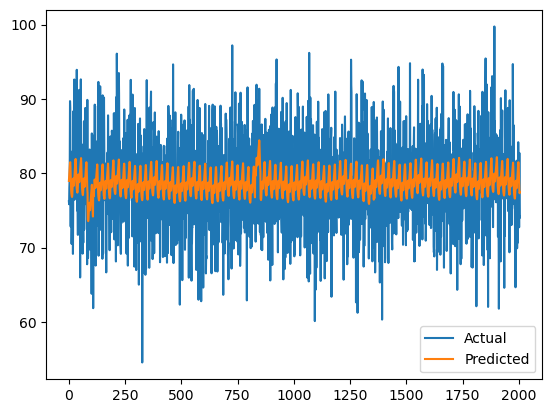

In [186]:
# plot expected vs actual
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()